# Analysis: Regional DSK model

In [1]:
from pathlib import Path
import sys

# Load reusable reader from scripts/read_batch_runs.py
project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import plotly.graph_objects as go

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.subplots import make_subplots

from scripts.read_batch_runs import (
    load_simulation_results_matrix,
    check_regional_consistency,
)
from scripts.visualise_shocks import *

## Define PATH

In [7]:
# define paths to experiment runs.
PATH1 = Path(
    "/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/homogenos_regions_homogenous_shocks"
)
PATH2 = Path(
    "/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/dsk_sfc"
)
PATH3 = None

In [8]:
homogenous_regions_homogenous_shocks = load_simulation_results_matrix(PATH1)
dsk_sfc = load_simulation_results_matrix(PATH2)

Found 3 scenario candidate folders under /Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/homogenos_regions_homogenous_shocks
Scenario 1: run_folders=50, max_run=50, macro_files_loaded=50, region_files_loaded=200, max_region=4, shock_files_loaded=0
  Scenario 1: saved to scenario_1.csv.gz
Scenario 2: run_folders=50, max_run=50, macro_files_loaded=50, region_files_loaded=200, max_region=4, shock_files_loaded=50
  Scenario 2: saved to scenario_2.csv.gz
Scenario 3: run_folders=50, max_run=50, macro_files_loaded=50, region_files_loaded=200, max_region=4, shock_files_loaded=50
  Scenario 3: saved to scenario_3.csv.gz
Consolidated shape=(450000, 114)
Found 3 scenario candidate folders under /Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/verifications/dsk_sfc
Column count mismatch: data_cols=28, yaml_cols=39.
Column count mismatch: data_cols=28, yaml_cols=39.
Column count mismatch: data_cols=28, yaml_cols=39.
Column count mismatch: data_cols=28, yaml_cols=39.
C

In [9]:
hrhs_scenario1 = homogenous_regions_homogenous_shocks[homogenous_regions_homogenous_shocks["scenario"] == 1]
hrhs_scenario2 = homogenous_regions_homogenous_shocks[homogenous_regions_homogenous_shocks["scenario"] == 2]
hrhs_scenario3 = homogenous_regions_homogenous_shocks[homogenous_regions_homogenous_shocks["scenario"] == 3]


dsk_scenario1 = dsk_sfc[dsk_sfc["scenario"] == 1]
dsk_scenario2 = dsk_sfc[dsk_sfc["scenario"] == 2]
dsk_scenario3 = dsk_sfc[dsk_sfc["scenario"] == 3]

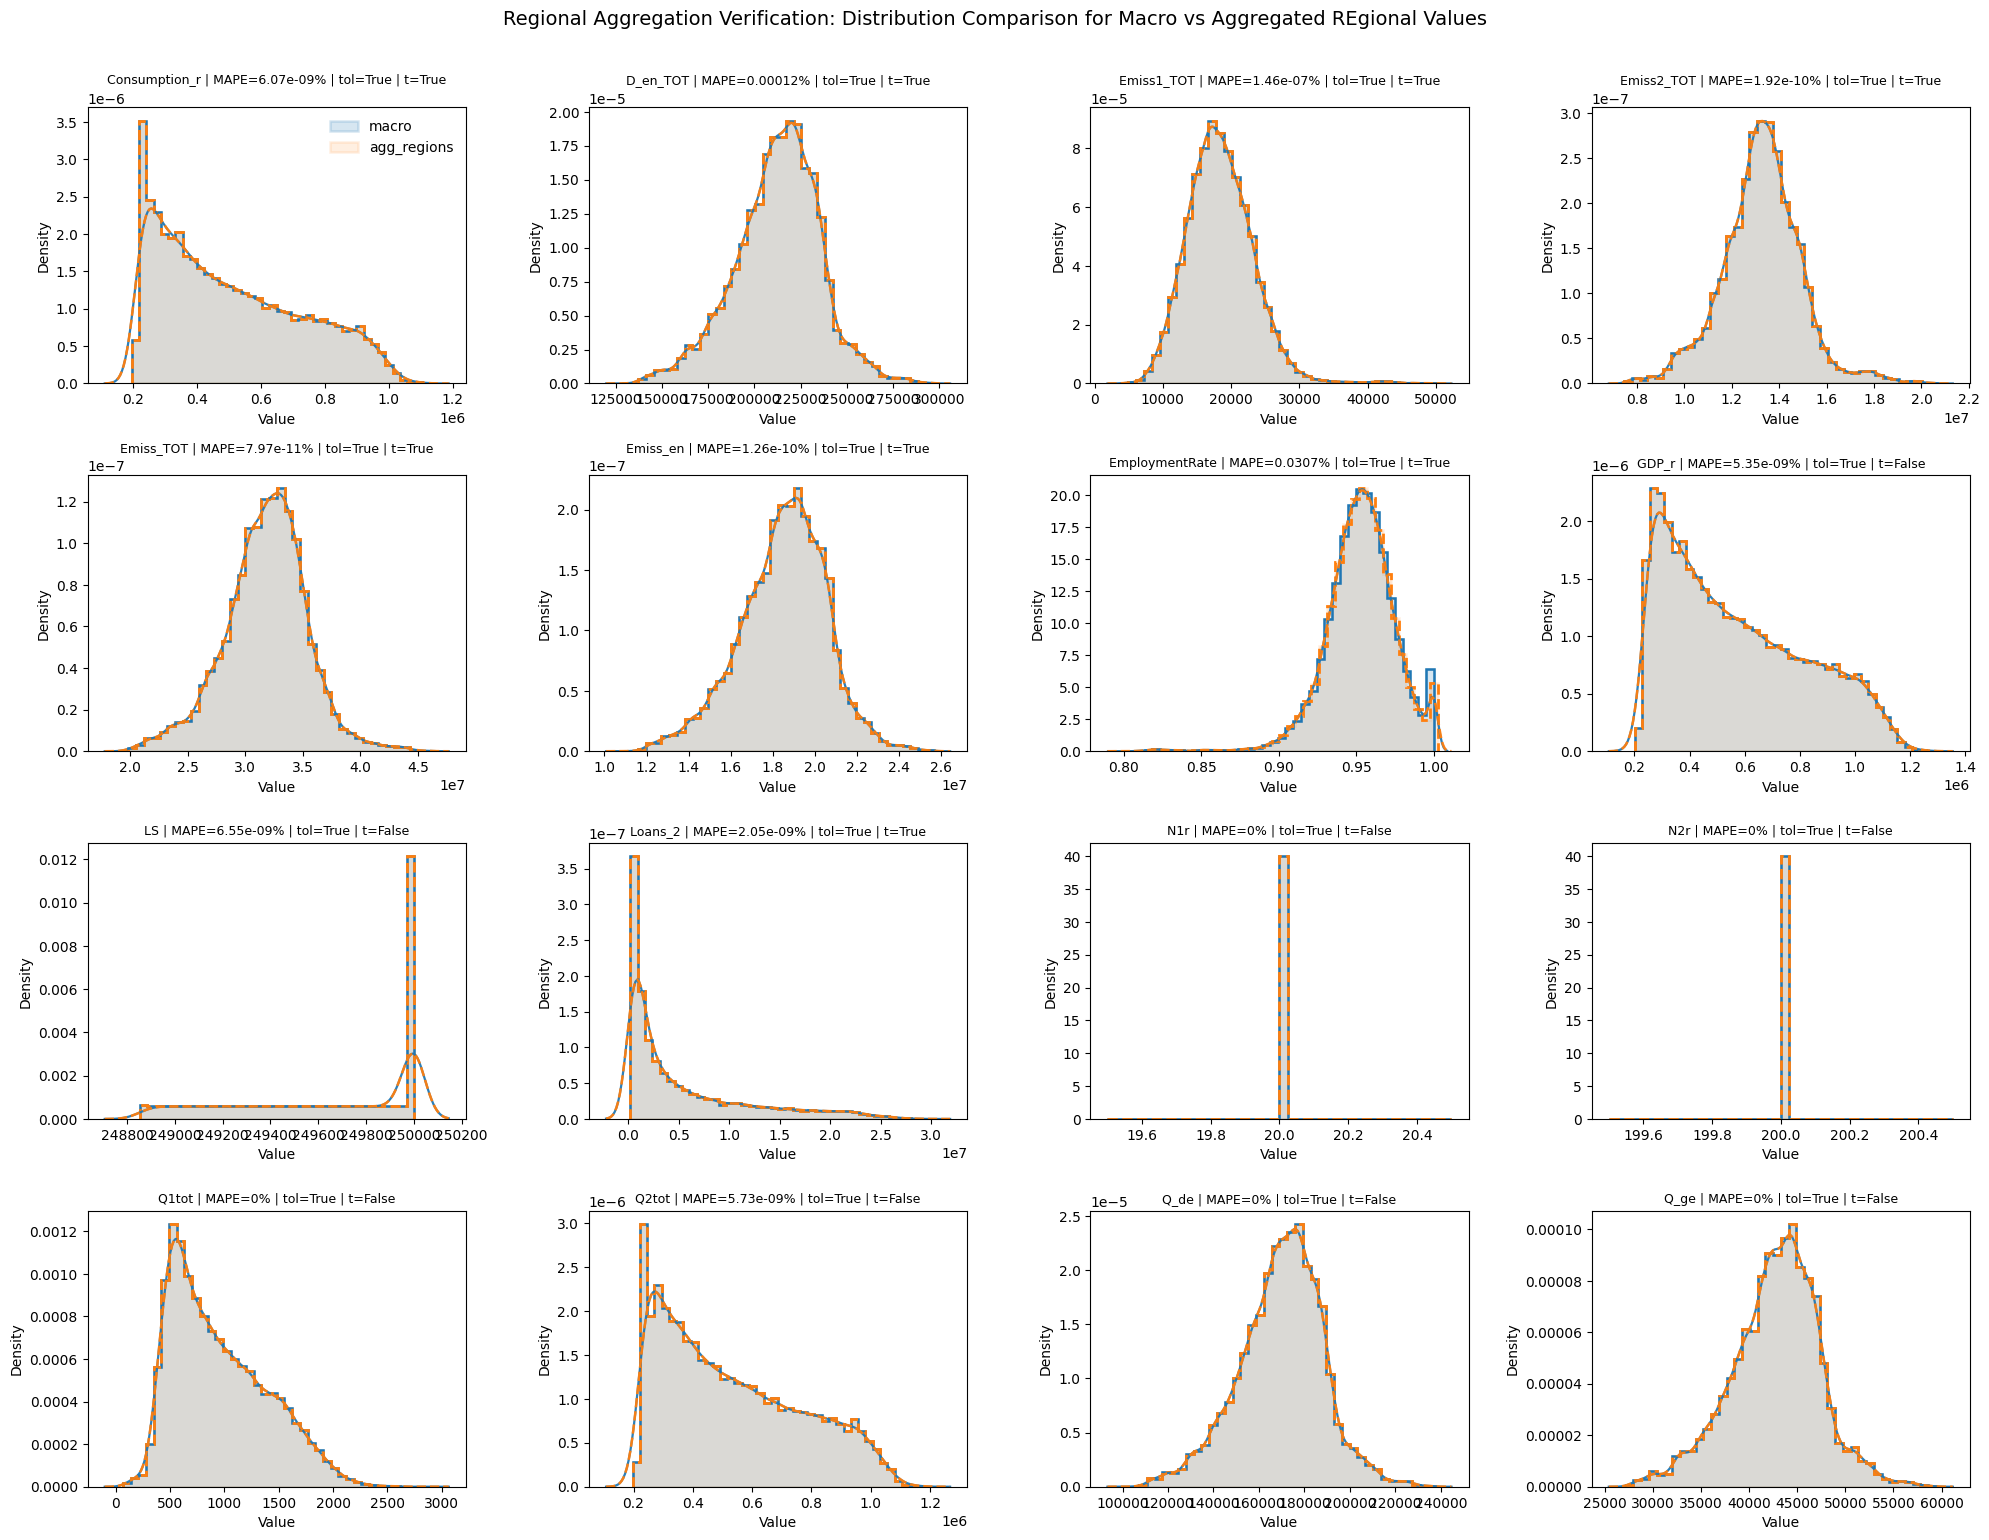

          variable  n_obs     mean_bias       mae      rmse  mean_abs_pct_err  \
0    Consumption_r  30000  1.385912e-08  0.000025  0.000029      6.068532e-09   
1         D_en_TOT  30000  7.368314e-04  0.251121  0.289429      1.196229e-04   
2       Emiss1_TOT  30000 -1.016616e-08  0.000025  0.000029      1.462628e-07   
3       Emiss2_TOT  30000 -1.401746e-08  0.000025  0.000029      1.917130e-10   
4        Emiss_TOT  30000 -3.221594e-08  0.000025  0.000029      7.974237e-11   
5         Emiss_en  30000  8.868029e-08  0.000023  0.000028      1.255513e-10   
6   EmploymentRate  30000  9.618082e-07  0.000292  0.000398      3.065026e-02   
7            GDP_r  30000 -3.961476e-07  0.000025  0.000029      5.349539e-09   
8               LS  30000 -1.011100e-06  0.000016  0.000023      6.550948e-09   
9          Loans_2  30000 -2.244701e-07  0.000025  0.000029      2.048948e-09   
10             N1r  30000  0.000000e+00  0.000000  0.000000      0.000000e+00   
11             N2r  30000  0

In [10]:
check_regional_consistency(
    hrhs_scenario1,
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-6,
)

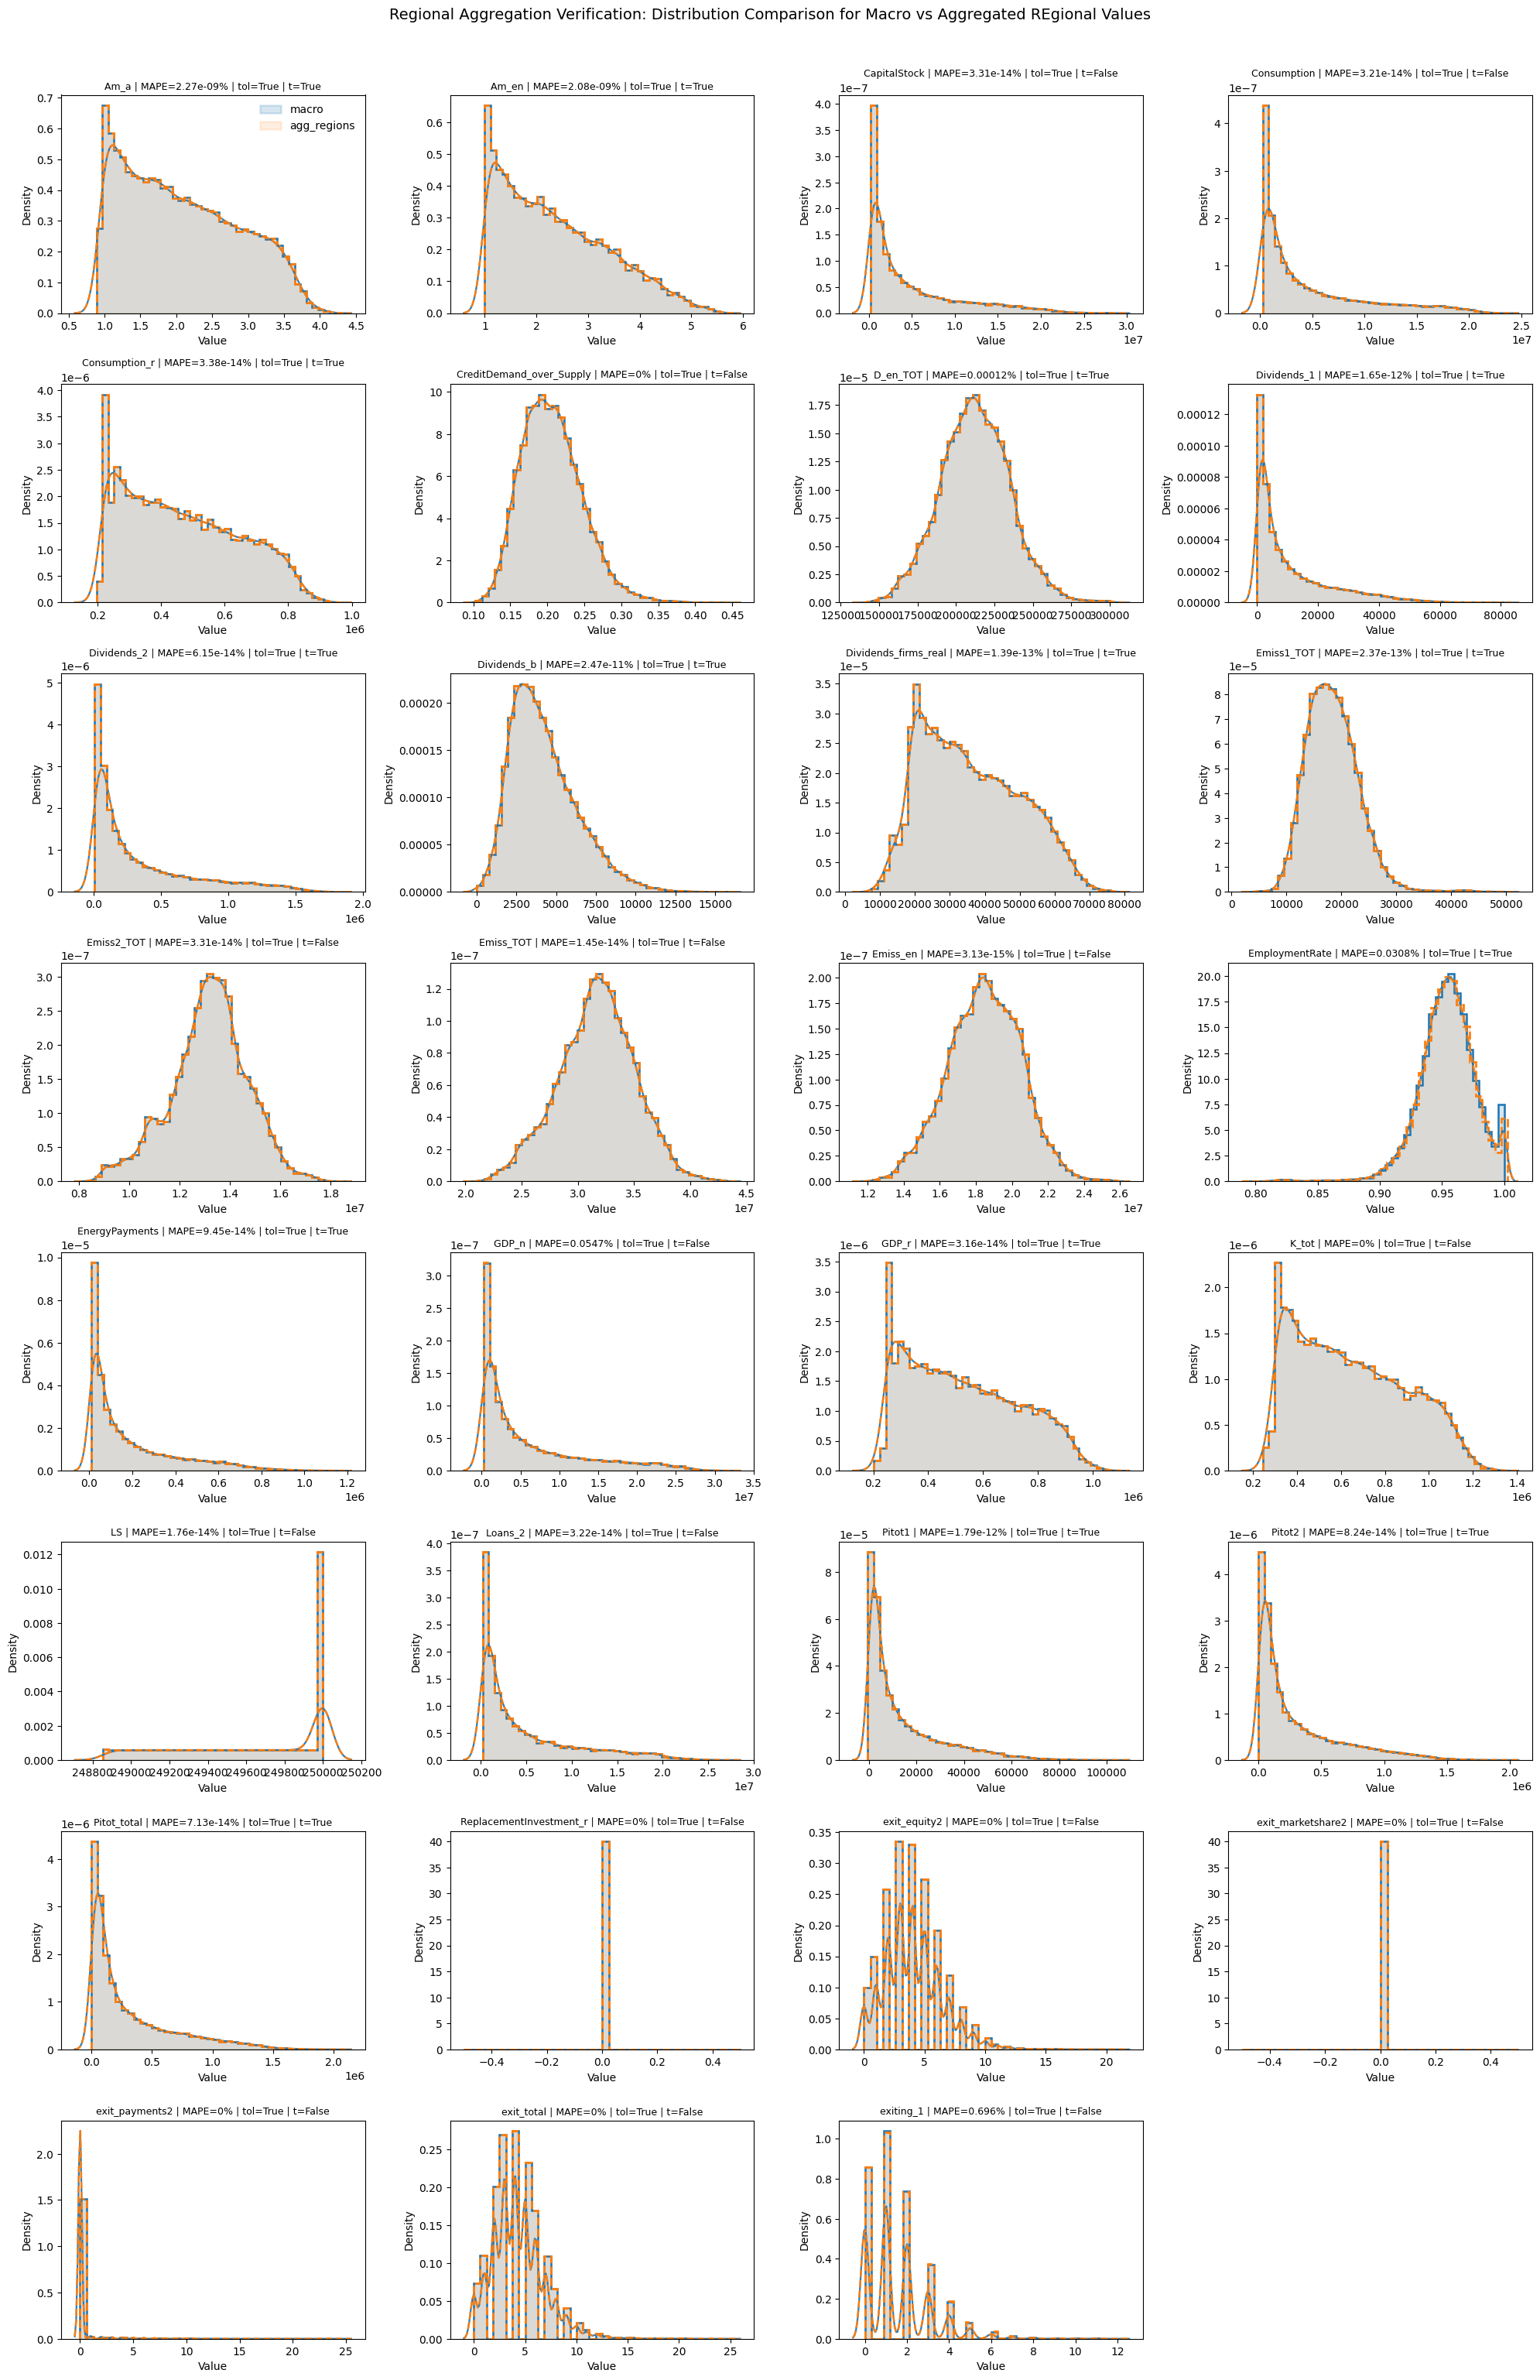

                    variable  n_obs     mean_bias           mae          rmse  \
0                       Am_a  30000  1.566687e-13  4.037669e-11  6.443343e-11   
1                      Am_en  30000  3.499998e-13  4.086337e-11  6.476367e-11   
2               CapitalStock  30000  1.112950e-10  1.592265e-09  3.029110e-09   
3                Consumption  30000  1.949501e-10  1.491782e-09  2.812576e-09   
4              Consumption_r  30000  1.197138e-12  1.560334e-10  2.113925e-10   
5   CreditDemand_over_Supply  30000  0.000000e+00  0.000000e+00  0.000000e+00   
6                   D_en_TOT  30000 -1.766229e-03  2.512561e-01  2.895582e-01   
7                Dividends_1  30000 -1.937933e-13  4.046322e-11  6.416234e-11   
8                Dividends_2  30000  1.927644e-12  1.198292e-10  2.069768e-10   
9                Dividends_b  30000 -4.777645e-13  4.106140e-11  6.477471e-11   
10      Dividends_firms_real  30000  1.644973e-13  4.256369e-11  6.605417e-11   
11                Emiss1_TOT

In [12]:
check_regional_consistency(
    hrhs_scenario3,
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-6,
)

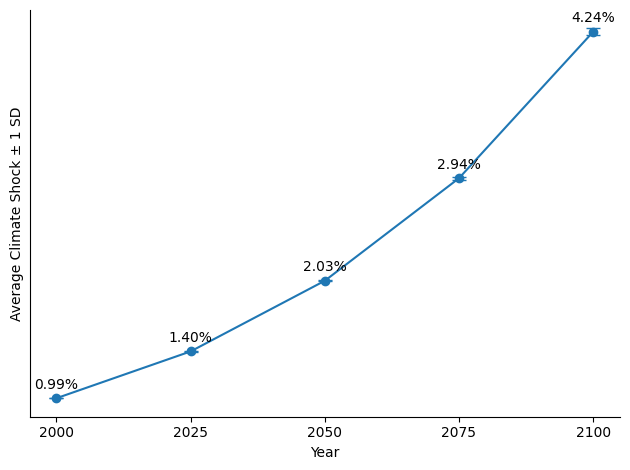

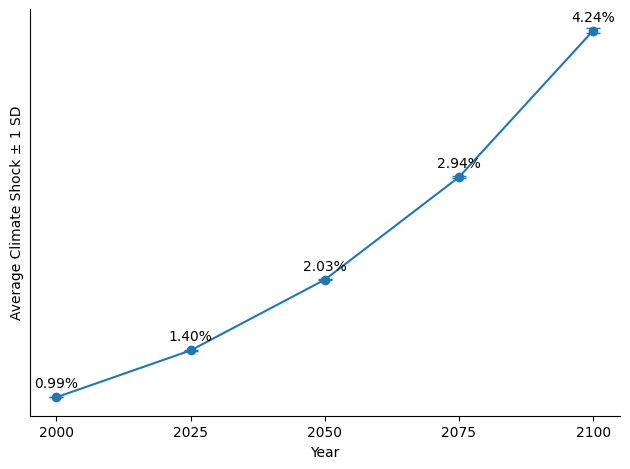

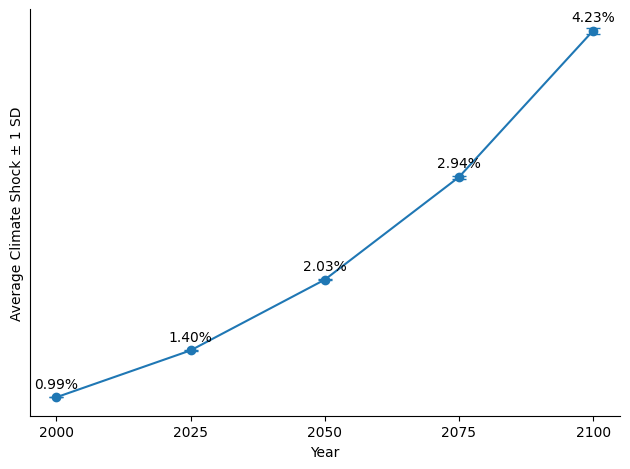

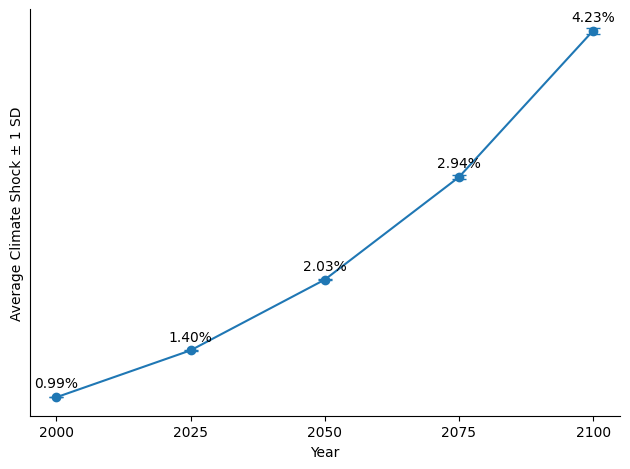

t,2000,2025,2050,2075,2100
mean,0.990099,1.404709,2.030072,2.937080,4.231962
std,0.000000,0.001524,0.006175,0.014104,0.026421
cv,0.000000,0.108527,0.304193,0.480207,0.624312


In [13]:
#  LP Shocks
get_shocks(hrhs_scenario2)
get_shocks(dsk_scenario2)

get_shocks(hrhs_scenario3)
get_shocks(dsk_scenario3)

In [14]:
# Compute GDP_r growth
def compute_gdp_r_growth(df):
    """Compute annualized GDP growth per row for panel simulation output.

    Growth is computed within each (scenario, run, region) trajectory as:
        ((GDP_r_t / GDP_r_t-1) ** 4 - 1) * 100
    where 4 annualizes quarter-over-quarter growth.

    Parameters
    ----------
    df : pandas.DataFrame
        Input frame containing at least: scenario, run, region, t, and GDP_r.

    Returns
    -------
    pandas.Series
        Annualized growth in percent, aligned to ``df.index``. The first
        timestep in each group is NaN.

    Raises
    ------
    KeyError
        If required grouping columns or a GDP column are missing.
    """
    required_group_cols = ["scenario", "run", "region", "t"]
    missing_group_cols = [col for col in required_group_cols if col not in df.columns]
    if missing_group_cols:
        raise KeyError(f"Missing required columns: {missing_group_cols}")

    gdp_col = "GDP_r" if "GDP_r" in df.columns else None
    if gdp_col is None:
        raise KeyError("Missing GDP column. Expected one of: 'GDP_r'")

    ordered = df[required_group_cols + [gdp_col]].sort_values(required_group_cols)
    prev_gdp = ordered.groupby(["scenario", "run", "region"], sort=False)[gdp_col].shift(1)

    growth = ((ordered[gdp_col] / prev_gdp) ** 4 - 1) * 100
    valid = (prev_gdp > 0) & (ordered[gdp_col] > 0)
    growth = growth.where(valid, np.nan)

    return growth.reindex(df.index)



def compute_GDP_r_volatility(df):
    """Compute annualized real GDP volatility per row for panel simulation output.

    Volatility is the expanding standard deviation of annualized GDP growth
    within each (scenario, run, region) trajectory.

    Parameters
    ----------
    df : pandas.DataFrame
        Input frame containing at least: scenario, run, region, t, and GDP_r.

    Returns
    -------
    pandas.Series
        Expanding standard deviation of annualized GDP growth (percentage points),
        aligned to ``df.index``. The first timestep in each group is NaN.

    Raises
    ------
    KeyError
        If required grouping columns or a GDP column are missing.
    """
    required_group_cols = ["scenario", "run", "region", "t"]
    missing_group_cols = [col for col in required_group_cols if col not in df.columns]
    if missing_group_cols:
        raise KeyError(f"Missing required columns: {missing_group_cols}")

    gdp_col = "GDP_r" if "GDP_r" in df.columns else None
    if gdp_col is None:
        raise KeyError("Missing GDP column. Expected one of: 'GDP_r'")

    ordered = df[required_group_cols + [gdp_col]].sort_values(required_group_cols).copy()
    prev_gdp = ordered.groupby(["scenario", "run", "region"], sort=False)[gdp_col].shift(1)

    growth = ((ordered[gdp_col] / prev_gdp) ** 4 - 1) * 100
    valid = (prev_gdp > 0) & (ordered[gdp_col] > 0)
    ordered["_growth"] = growth.where(valid, np.nan)

    volatility = ordered.groupby(["scenario", "run", "region"], sort=False)["_growth"].transform(
        lambda s: s.expanding(min_periods=2).std()
    )

    return volatility.reindex(df.index)



def compute_crisis_indicator(df, threshold=-5.0):
    """Create a binary crisis indicator from annual GDP growth (%).

    A crisis is defined as GDP_r_growth < threshold. With GDP_r_growth in percent,
    Lamperti et al. (2018) threshold is -5.0.

    Returns a row-aligned Series (1 = crisis, 0 = no crisis, NaN if growth is NaN).
    """
    required_cols = ["GDP_r_growth"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")

    growth = df["GDP_r_growth"]
    out = growth.astype(float).copy()
    out.loc[:] = np.where(growth.notna(), (growth < threshold).astype(int), np.nan)
    return out.rename("crisis")

def compute_crisis_likelihood(
    df,
    group_cols=("run",),
    t_min=None,
    t_max=None,
    crisis_col="crisis",
):
    """Compute crisis likelihood by groups and optional time window.

    Likelihood = sum(crisis) / number_of_non_null_crisis_observations
    where crisis is a binary column (0/1).

    Parameters
    ----------
    df : pandas.DataFrame
        Input data containing group columns, timestep ``t`` (if filtered), and crisis column.
    group_cols : tuple[str, ...], default ("run",)
        Grouping dimensions for likelihood calculation.
    t_min : int | None, default None
        If provided, include observations with t >= t_min.
    t_max : int | None, default None
        If provided, include observations with t <= t_max.
    crisis_col : str, default "crisis"
        Name of crisis indicator column (binary 0/1).

    Returns
    -------
    pandas.Series
        Crisis likelihood by ``group_cols`` as float values in [0, 1].
    """
    required_cols = list(group_cols) + [crisis_col]
    if t_min is not None or t_max is not None:
        required_cols.append("t")

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")

    work = df.copy()

    # Optional timestep filtering
    if t_min is not None:
        work = work[work["t"] >= t_min]
    if t_max is not None:
        work = work[work["t"] <= t_max]

    # Use only non-null crisis observations
    valid_obs = work[crisis_col].notna()
    obs_count = work[valid_obs].groupby(list(group_cols), sort=False)[crisis_col].count()
    crisis_sum = work[valid_obs].groupby(list(group_cols), sort=False)[crisis_col].sum()

    return (crisis_sum / obs_count.replace(0, np.nan)).astype(float).rename("crisis_likelihood")



In [16]:
#  Compute unemployment
# For HRHS
hrhs_scenario1['Unemployment'] = (1 - hrhs_scenario1.EmploymentRate) * 100
hrhs_scenario2['Unemployment'] = (1 - hrhs_scenario2.EmploymentRate) * 100
hrhs_scenario3['Unemployment'] = (1 - hrhs_scenario3.EmploymentRate) * 100
# For DSK
dsk_scenario1['Unemployment'] = (1 - dsk_scenario1.EmploymentRate) * 100
dsk_scenario2['Unemployment'] = (1 - dsk_scenario2.EmploymentRate) * 100
dsk_scenario3['Unemployment'] = (1 - dsk_scenario3.EmploymentRate) * 100

# Compute GDP volatility
# FOR HRHS
hrhs_scenario1['GDP_r_volatility'] = compute_GDP_r_volatility(hrhs_scenario1)
hrhs_scenario2['GDP_r_volatility'] = compute_GDP_r_volatility(hrhs_scenario2)
hrhs_scenario3['GDP_r_volatility'] = compute_GDP_r_volatility(hrhs_scenario3)
# FOR DSK
dsk_scenario1['GDP_r_volatility'] = compute_GDP_r_volatility(dsk_scenario1)
dsk_scenario2['GDP_r_volatility'] = compute_GDP_r_volatility(dsk_scenario2)
dsk_scenario3['GDP_r_volatility'] = compute_GDP_r_volatility(dsk_scenario3)

#  Compute Output Growth Rate
# For HRHS
hrhs_scenario1['GDP_r_growth'] = compute_gdp_r_growth(hrhs_scenario1)
hrhs_scenario2['GDP_r_growth'] = compute_gdp_r_growth(hrhs_scenario2)
hrhs_scenario3['GDP_r_growth'] = compute_gdp_r_growth(hrhs_scenario3)
# For DSK
dsk_scenario1['GDP_r_growth'] = compute_gdp_r_growth(dsk_scenario1)
dsk_scenario2['GDP_r_growth'] = compute_gdp_r_growth(dsk_scenario2)
dsk_scenario3['GDP_r_growth'] = compute_gdp_r_growth(dsk_scenario3)

In [17]:

def compare_scenarios(df_a, df_b, metric, t_min=200, label_a="DSK", label_b="HRHS", alpha=0.05):
    """Compare a metric between two scenario DataFrames using Welch's t-test.

    Observations are first averaged per Monte Carlo run (over t > t_min),
    so each run contributes exactly one independent data point to the test.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``, and ``metric``.
    metric : str
        Column name to compare (e.g. 'Unemployment', 'GDP_r_growth').
    t_min : int, default 200
        Only include observations with t > t_min before averaging.
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    # Filter to macro region if multiple regions present
    if "region" in df_a.columns and df_a["region"].nunique() > 1:
        df_a = df_a[df_a["region"] == "macro"]
    if "region" in df_b.columns and df_b["region"].nunique() > 1:
        df_b = df_b[df_b["region"] == "macro"]

    # Aggregate to run-level means (one independent observation per run)
    a = (
        df_a.loc[df_a["t"] > t_min, ["run", metric]]
        .groupby("run")[metric].mean()
        .dropna()
    )
    b = (
        df_b.loc[df_b["t"] > t_min, ["run", metric]]
        .groupby("run")[metric].mean()
        .dropna()
    )

    print(f"Metric : {metric}  (t > {t_min},  aggregated to run-level means)")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    # Welch's t-test on run-level means
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)
    print(f"\n  Welch's t-test  (H0: equal means across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")
    print()


def compare_crisis_likelihood(df_a, df_b, t_min=200, threshold=-5.0,
                               label_a="DSK", label_b="HRHS", alpha=0.05):
    """Compare per-run crisis likelihood between two scenario DataFrames.

    For each run, crisis likelihood = proportion of quarters (t > t_min)
    where GDP_r_growth < threshold. The resulting per-run likelihoods are
    then compared with Welch's t-test, giving one independent observation
    per Monte Carlo run.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``,
        and ``GDP_r_growth``.
    t_min : int, default 200
        Only include observations with t > t_min.
    threshold : float, default -5.0
        Crisis threshold in percent (Lamperti et al. 2018: -5.0).
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    def _run_level_likelihood(df):
        # Filter to macro region if multiple regions present
        if "region" in df.columns and df["region"].nunique() > 1:
            df = df[df["region"] == "macro"]

        work = df.loc[df["t"] > t_min, ["run", "GDP_r_growth"]].copy()
        valid = work["GDP_r_growth"].notna()

        # Binary crisis flag per row
        work["_crisis"] = np.where(valid, (work["GDP_r_growth"] < threshold).astype(int), np.nan)

        # Per-run likelihood = crisis quarters / valid quarters
        obs   = work[valid].groupby("run")["_crisis"].count()
        crises = work[valid].groupby("run")["_crisis"].sum()
        return (crises / obs.replace(0, np.nan)).astype(float).dropna()

    a = _run_level_likelihood(df_a)
    b = _run_level_likelihood(df_b)

    print(f"Crisis likelihood  (GDP_r_growth < {threshold}%,  t > {t_min})")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)
    print(f"\n  Welch's t-test  (H0: equal crisis likelihood across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")
    print()


# --- usage: scenario 1 ---
compare_scenarios(dsk_scenario1, hrhs_scenario1, metric="Unemployment")
compare_scenarios(dsk_scenario1, hrhs_scenario1, metric="GDP_r_growth")
compare_scenarios(dsk_scenario1, hrhs_scenario1, metric="GDP_r_volatility")
compare_crisis_likelihood(dsk_scenario1, hrhs_scenario1)

Metric : Unemployment  (t > 200,  aggregated to run-level means)
  DSK         mean=4.7049  std=0.2257  n_runs=50
  HRHS        mean=4.7049  std=0.2257  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.0000
    p-value     : 1.0000e+00
    Significant : No (α = 0.05)

Metric : GDP_r_growth  (t > 200,  aggregated to run-level means)
  DSK         mean=1.3113  std=0.0785  n_runs=50
  HRHS        mean=1.3113  std=0.0785  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.0000
    p-value     : 1.0000e+00
    Significant : No (α = 0.05)

Metric : GDP_r_volatility  (t > 200,  aggregated to run-level means)
  DSK         mean=8.2887  std=0.6299  n_runs=50
  HRHS        mean=8.2887  std=0.6299  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.0000
    p-value     : 1.0000e+00
    Significant : No (α = 0.05)

Crisis likelihood  (GDP_r_growth < -5.0%,  t > 200)
  DSK         mean=0.1676  std=0.0147  n_runs=5

In [18]:
# --- usage: scenario 2 ---
compare_scenarios(dsk_scenario2, hrhs_scenario2, metric="Unemployment")
compare_scenarios(dsk_scenario2, hrhs_scenario2, metric="GDP_r_growth")
compare_scenarios(dsk_scenario2, hrhs_scenario2, metric="GDP_r_volatility")
compare_crisis_likelihood(dsk_scenario2, hrhs_scenario2)

Metric : Unemployment  (t > 200,  aggregated to run-level means)
  DSK         mean=4.5489  std=0.1858  n_runs=50
  HRHS        mean=4.5061  std=0.1836  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 1.1586
    p-value     : 2.4945e-01
    Significant : No (α = 0.05)

Metric : GDP_r_growth  (t > 200,  aggregated to run-level means)
  DSK         mean=1.3556  std=0.0639  n_runs=50
  HRHS        mean=1.3757  std=0.0685  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -1.5207
    p-value     : 1.3157e-01
    Significant : No (α = 0.05)

Metric : GDP_r_volatility  (t > 200,  aggregated to run-level means)
  DSK         mean=8.5694  std=0.6242  n_runs=50
  HRHS        mean=8.6543  std=0.6040  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.6909
    p-value     : 4.9128e-01
    Significant : No (α = 0.05)

Crisis likelihood  (GDP_r_growth < -5.0%,  t > 200)
  DSK         mean=0.1774  std=0.0156  n_runs

In [19]:
# --- usage: scenario 3 ---
compare_scenarios(dsk_scenario3, hrhs_scenario3, metric="Unemployment")
compare_scenarios(dsk_scenario3, hrhs_scenario3, metric="GDP_r_growth")
compare_scenarios(dsk_scenario3, hrhs_scenario3, metric="GDP_r_volatility")
compare_crisis_likelihood(dsk_scenario3, hrhs_scenario3)

Metric : Unemployment  (t > 200,  aggregated to run-level means)
  DSK         mean=4.5187  std=0.2035  n_runs=50
  HRHS        mean=4.5062  std=0.1982  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.3104
    p-value     : 7.5690e-01
    Significant : No (α = 0.05)

Metric : GDP_r_growth  (t > 200,  aggregated to run-level means)
  DSK         mean=1.1078  std=0.0554  n_runs=50
  HRHS        mean=1.1387  std=0.0615  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -2.6363
    p-value     : 9.7613e-03
    Significant : Yes (α = 0.05)

Metric : GDP_r_volatility  (t > 200,  aggregated to run-level means)
  DSK         mean=8.2740  std=0.6003  n_runs=50
  HRHS        mean=8.3520  std=0.7062  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -0.5951
    p-value     : 5.5316e-01
    Significant : No (α = 0.05)

Crisis likelihood  (GDP_r_growth < -5.0%,  t > 200)
  DSK         mean=0.1807  std=0.0171  n_run

In [25]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Scenario registry ────────────────────────────────────────────────────────
SCENARIOS = {
    "No Shock": {"df": dsk_scenario1, "color": "grey"},
    "CS":       {"df": dsk_scenario2, "color": "green"},
    "LP + EF":       {"df": dsk_scenario3, "color": "red"},
}

MARKER_TS  = {200, 300, 400, 500, 600}
X_RANGE    = [200, 600]
CRISIS_THR = -5.0   # % (Lamperti et al. 2018)

# ── Helper: restrict to macro region ────────────────────────────────────────
def _macro(df):
    if "region" in df.columns and df["region"].nunique() > 1:
        return df[df["region"] == "macro"]
    return df

# ── Aggregation helpers ──────────────────────────────────────────────────────
def _ts_stats(df, metric):
    """
    Run-level mean per t, then cross-run mean ± std at each t.
    Returns (mean_series, std_series) indexed by t.
    """
    work = _macro(df)[["run", "t", metric]].dropna(subset=[metric])
    by_t = work.groupby(["t", "run"])[metric].mean().groupby("t")
    return by_t.mean(), by_t.std().fillna(0)

def _crisis_ts_stats(df, threshold=CRISIS_THR):
    """
    Per-run crisis proportion at each t (crisis = GDP_r_growth < threshold),
    then cross-run mean ± std.
    """
    work = _macro(df)[["run", "t", "GDP_r_growth"]].dropna(subset=["GDP_r_growth"]).copy()
    work["_crisis"] = (work["GDP_r_growth"] < threshold).astype(float)
    by_t = work.groupby(["t", "run"])["_crisis"].mean().groupby("t")
    return by_t.mean(), by_t.std().fillna(0)

# ── Panel definitions: (col_key, y-axis label, stats_fn) ────────────────────
PANELS = [
    ("Unemployment",     "Unemployment (%)",   _ts_stats),
    ("GDP_r_growth",     "GDP Growth (%)",     _ts_stats),
    ("GDP_r_volatility", "GDP Volatility (%)   ", _ts_stats),
    ("crisis",           "Crisis Likelihood",  None),        # uses _crisis_ts_stats
]
POSITIONS = [(1, 1), (1, 2), (2, 1), (2, 2)]

# ── Build figure ─────────────────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[p[1].strip() for p in PANELS],
    vertical_spacing=0.14,
    horizontal_spacing=0.10,
)

ci_trace_indices = []   # indices of band traces for the toggle button

for scenario_name, spec in SCENARIOS.items():
    df    = spec["df"]
    color = spec["color"]

    for panel_i, (metric, ylabel, fn) in enumerate(PANELS):
        row, col = POSITIONS[panel_i]

        # --- compute time-series stats -----------------------------------------
        if metric == "crisis":
            mean_ts, std_ts = _crisis_ts_stats(df)
        else:
            mean_ts, std_ts = fn(df, metric)

        # --- restrict to x range -----------------------------------------------
        mask   = (mean_ts.index >= X_RANGE[0]) & (mean_ts.index <= X_RANGE[1])
        t_vals = mean_ts.index[mask].values
        m_vals = mean_ts.values[mask]
        s_vals = std_ts.reindex(mean_ts.index[mask]).fillna(0).values

        # markers only at the 5 key timesteps
        m_sizes  = [8 if int(t) in MARKER_TS else 0 for t in t_vals]
        m_syms   = ["circle" if int(t) in MARKER_TS else "circle" for t in t_vals]

        show_legend = (panel_i == 0)   # add each scenario to legend once

        # --- mean line ---------------------------------------------------------
        fig.add_trace(
            go.Scatter(
                x=t_vals,
                y=m_vals,
                mode="lines+markers",
                name=scenario_name,
                line=dict(color=color, width=2),
                marker=dict(
                    color=[color if s > 0 else "rgba(0,0,0,0)" for s in m_sizes],
                    size=m_sizes,
                    symbol=m_syms,
                    line=dict(color=color, width=1),
                ),
                legendgroup=scenario_name,
                showlegend=show_legend,
            ),
            row=row, col=col,
        )

        # --- confidence band (+/- 1 SD) ----------------------------------------
        ci_trace_indices.append(len(fig.data))
        fig.add_trace(
            go.Scatter(
                x=np.concatenate([t_vals, t_vals[::-1]]),
                y=np.concatenate([m_vals + s_vals, (m_vals - s_vals)[::-1]]),
                fill="toself",
                fillcolor=color,
                opacity=0.12,
                line=dict(width=0),
                name=f"{scenario_name} ±1 SD",
                legendgroup=f"{scenario_name}_ci",
                showlegend=False,   # bands toggled via button, not legend
                visible=True,
                hoverinfo="skip",
            ),
            row=row, col=col,
        )

# ── Axis formatting ──────────────────────────────────────────────────────────
for r, c in POSITIONS:
    fig.update_xaxes(range=X_RANGE, title_text="Timestep (t)", row=r, col=c,
                     tickvals=list(MARKER_TS))

for i, (_, ylabel, _fn) in enumerate(PANELS):
    r, c = POSITIONS[i]
    fig.update_yaxes(title_text=ylabel.strip(), row=r, col=c)

# ── CI show / hide toggle buttons ────────────────────────────────────────────
fig.update_layout(
    height=740,
    width=1100,
    title_text="Macroeconomic Indicators Across Scenarios",
    title_x=0.5,
    template="simple_white",
    legend=dict(
        tracegroupgap=4,
        x=1.01, y=1.0,
        title_text="Scenario",
    ),
    updatemenus=[dict(
        type="buttons",
        direction="left",
        x=0.0, y=1.065,
        xanchor="left",
        pad={"r": 8, "t": 4},
        bgcolor="#f0f0f0",
        bordercolor="#aaa",
        buttons=[
            dict(
                label="Show ±1 SD bands",
                method="restyle",
                args=[{"visible": True}, ci_trace_indices],
            ),
            dict(
                label="Hide ±1 SD bands",
                method="restyle",
                args=[{"visible": "legendonly"}, ci_trace_indices],
            ),
        ],
    )],
)

fig.show()

## Compare Macro-level variables
### Homogenous Regions & Homogenous Shocks

In [26]:
# ── Config (shared with cell above) ─────────────────────────────────────────
SCENARIOS = {
    "No Shock": {"df": hrhs_scenario1, "color": "grey"},
    "CS":       {"df": hrhs_scenario2, "color": "green"},
    "LP + EF":       {"df": hrhs_scenario3, "color": "red"},
}

SNAP_TS    = sorted([200, 300, 400, 500, 600])   # only these t values
CRISIS_THR = -5.0

# ── Helpers ──────────────────────────────────────────────────────────────────
def _macro(df):
    if "region" in df.columns and df["region"].nunique() > 1:
        return df[df["region"] == "macro"]
    return df

def _snap_stats(df, metric):
    """Cross-run mean ± std at each snapshot timestep only."""
    work = _macro(df)
    work = work[work["t"].isin(SNAP_TS)][["run", "t", metric]].dropna(subset=[metric])
    by_t = work.groupby(["t", "run"])[metric].mean().groupby("t")
    return by_t.mean(), by_t.std().fillna(0)

def _crisis_snap_stats(df, threshold=CRISIS_THR):
    """Per-run crisis proportion at each snapshot timestep only."""
    work = _macro(df)
    work = work[work["t"].isin(SNAP_TS)][["run", "t", "GDP_r_growth"]].dropna(subset=["GDP_r_growth"]).copy()
    work["_crisis"] = (work["GDP_r_growth"] < threshold).astype(float)
    by_t = work.groupby(["t", "run"])["_crisis"].mean().groupby("t")
    return by_t.mean(), by_t.std().fillna(0)

# ── Panel definitions ────────────────────────────────────────────────────────
PANELS = [
    ("Unemployment",     "Unemployment (%)",    _snap_stats),
    ("GDP_r_growth",     "GDP Growth (%)",      _snap_stats),
    ("GDP_r_volatility", "GDP Volatility (%)",  _snap_stats),
    ("crisis",           "Crisis Likelihood",   None),
]
POSITIONS = [(1, 1), (1, 2), (2, 1), (2, 2)]

# ── Build figure ─────────────────────────────────────────────────────────────
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=[p[1] for p in PANELS],
    vertical_spacing=0.14,
    horizontal_spacing=0.10,
)

ci_trace_indices2 = []

for scenario_name, spec in SCENARIOS.items():
    df    = spec["df"]
    color = spec["color"]

    for panel_i, (metric, ylabel, fn) in enumerate(PANELS):
        row, col = POSITIONS[panel_i]

        if metric == "crisis":
            mean_ts, std_ts = _crisis_snap_stats(df)
        else:
            mean_ts, std_ts = fn(df, metric)

        t_vals = mean_ts.index.values
        m_vals = mean_ts.values
        s_vals = std_ts.reindex(mean_ts.index).fillna(0).values

        show_legend = (panel_i == 0)

        # Mean line — only 5 points, connected by straight segments
        fig2.add_trace(
            go.Scatter(
                x=t_vals,
                y=m_vals,
                mode="lines+markers",
                name=scenario_name,
                line=dict(color=color, width=2),
                marker=dict(color=color, size=8, symbol="circle",
                            line=dict(color=color, width=1)),
                legendgroup=scenario_name,
                showlegend=show_legend,
            ),
            row=row, col=col,
        )

        # CI band
        ci_trace_indices2.append(len(fig2.data))
        fig2.add_trace(
            go.Scatter(
                x=np.concatenate([t_vals, t_vals[::-1]]),
                y=np.concatenate([m_vals + s_vals, (m_vals - s_vals)[::-1]]),
                fill="toself",
                fillcolor=color,
                opacity=0.12,
                line=dict(width=0),
                name=f"{scenario_name} ±1 SD",
                legendgroup=f"{scenario_name}_ci",
                showlegend=False,
                visible=True,
                hoverinfo="skip",
            ),
            row=row, col=col,
        )

# ── Axis formatting ───────────────────────────────────────────────────────────
for r, c in POSITIONS:
    fig2.update_xaxes(range=[190, 610], title_text="Timestep (t)", row=r, col=c,
                      tickvals=SNAP_TS)

for i, (_, ylabel, _fn) in enumerate(PANELS):
    r, c = POSITIONS[i]
    fig2.update_yaxes(title_text=ylabel, row=r, col=c)

# ── Toggle buttons ────────────────────────────────────────────────────────────
fig2.update_layout(
    height=740,
    width=1100,
    title_text="Macroeconomic Indicators Across Scenarios (Snapshot: t = 200, 300, 400, 500, 600)",
    title_x=0.5,
    template="simple_white",
    legend=dict(tracegroupgap=4, x=1.01, y=1.0, title_text="Scenario"),
    updatemenus=[dict(
        type="buttons",
        direction="left",
        x=0.0, y=1.065,
        xanchor="left",
        pad={"r": 8, "t": 4},
        bgcolor="#f0f0f0",
        bordercolor="#aaa",
        buttons=[
            dict(label="Show ±1 SD bands", method="restyle",
                 args=[{"visible": True}, ci_trace_indices2]),
            dict(label="Hide ±1 SD bands", method="restyle",
                 args=[{"visible": "legendonly"}, ci_trace_indices2]),
        ],
    )],
)

fig2.show()


### SFC-DSK

In [27]:
# ── Config (shared with cell above) ─────────────────────────────────────────
SCENARIOS = {
    "No Shock": {"df": dsk_scenario1, "color": "grey"},
    "CP":       {"df": dsk_scenario2, "color": "green"},
    "EF + LP":       {"df": dsk_scenario3, "color": "red"},
}

SNAP_TS    = sorted([200, 300, 400, 500, 600])   # only these t values
CRISIS_THR = -5.0

# ── Helpers ──────────────────────────────────────────────────────────────────
def _macro(df):
    if "region" in df.columns and df["region"].nunique() > 1:
        return df[df["region"] == "macro"]
    return df

def _snap_stats(df, metric):
    """Cross-run mean ± std at each snapshot timestep only."""
    work = _macro(df)
    work = work[work["t"].isin(SNAP_TS)][["run", "t", metric]].dropna(subset=[metric])
    by_t = work.groupby(["t", "run"])[metric].mean().groupby("t")
    return by_t.mean(), by_t.std().fillna(0)

def _crisis_snap_stats(df, threshold=CRISIS_THR):
    """Per-run crisis proportion at each snapshot timestep only."""
    work = _macro(df)
    work = work[work["t"].isin(SNAP_TS)][["run", "t", "GDP_r_growth"]].dropna(subset=["GDP_r_growth"]).copy()
    work["_crisis"] = (work["GDP_r_growth"] < threshold).astype(float)
    by_t = work.groupby(["t", "run"])["_crisis"].mean().groupby("t")
    return by_t.mean(), by_t.std().fillna(0)

# ── Panel definitions ────────────────────────────────────────────────────────
PANELS = [
    ("Unemployment",     "Unemployment (%)",    _snap_stats),
    ("GDP_r_growth",     "GDP Growth (%)",      _snap_stats),
    ("GDP_r_volatility", "GDP Volatility (%)",  _snap_stats),
    ("crisis",           "Crisis Likelihood",   None),
]
POSITIONS = [(1, 1), (1, 2), (2, 1), (2, 2)]

# ── Build figure ─────────────────────────────────────────────────────────────
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=[p[1] for p in PANELS],
    vertical_spacing=0.14,
    horizontal_spacing=0.10,
)

ci_trace_indices2 = []

for scenario_name, spec in SCENARIOS.items():
    df    = spec["df"]
    color = spec["color"]

    for panel_i, (metric, ylabel, fn) in enumerate(PANELS):
        row, col = POSITIONS[panel_i]

        if metric == "crisis":
            mean_ts, std_ts = _crisis_snap_stats(df)
        else:
            mean_ts, std_ts = fn(df, metric)

        t_vals = mean_ts.index.values
        m_vals = mean_ts.values
        s_vals = std_ts.reindex(mean_ts.index).fillna(0).values

        show_legend = (panel_i == 0)

        # Mean line — only 5 points, connected by straight segments
        fig2.add_trace(
            go.Scatter(
                x=t_vals,
                y=m_vals,
                mode="lines+markers",
                name=scenario_name,
                line=dict(color=color, width=2),
                marker=dict(color=color, size=8, symbol="circle",
                            line=dict(color=color, width=1)),
                legendgroup=scenario_name,
                showlegend=show_legend,
            ),
            row=row, col=col,
        )

        # CI band
        ci_trace_indices2.append(len(fig2.data))
        fig2.add_trace(
            go.Scatter(
                x=np.concatenate([t_vals, t_vals[::-1]]),
                y=np.concatenate([m_vals + s_vals, (m_vals - s_vals)[::-1]]),
                fill="toself",
                fillcolor=color,
                opacity=0.12,
                line=dict(width=0),
                name=f"{scenario_name} ±1 SD",
                legendgroup=f"{scenario_name}_ci",
                showlegend=False,
                visible=True,
                hoverinfo="skip",
            ),
            row=row, col=col,
        )

# ── Axis formatting ───────────────────────────────────────────────────────────
for r, c in POSITIONS:
    fig2.update_xaxes(range=[190, 610], title_text="Timestep (t)", row=r, col=c,
                      tickvals=SNAP_TS)

for i, (_, ylabel, _fn) in enumerate(PANELS):
    r, c = POSITIONS[i]
    fig2.update_yaxes(title_text=ylabel, row=r, col=c)

# ── Toggle buttons ────────────────────────────────────────────────────────────
fig2.update_layout(
    height=740,
    width=1100,
    title_text="Macroeconomic Indicators Across Scenarios (Snapshot: t = 200, 300, 400, 500, 600)",
    title_x=0.5,
    template="simple_white",
    legend=dict(tracegroupgap=4, x=1.01, y=1.0, title_text="Scenario"),
    updatemenus=[dict(
        type="buttons",
        direction="left",
        x=0.0, y=1.065,
        xanchor="left",
        pad={"r": 8, "t": 4},
        bgcolor="#f0f0f0",
        bordercolor="#aaa",
        buttons=[
            dict(label="Show ±1 SD bands", method="restyle",
                 args=[{"visible": True}, ci_trace_indices2]),
            dict(label="Hide ±1 SD bands", method="restyle",
                 args=[{"visible": "legendonly"}, ci_trace_indices2]),
        ],
    )],
)

fig2.show()


In [29]:
# ── Shared config for per-region comparison plots ────────────────────────────
# Integer keys = sub-regions; "macro" = aggregate.  Macro is shown last,
# in black, with a slightly thicker line so it stands out clearly.
REGION_COLORS  = {
    1:       "steelblue",
    2:       "crimson",
    3:       "forestgreen",
    4:       "darkorange",
    "macro": "black",
}
SNAP_TS_REG    = [200, 300, 400, 500, 600]
CRISIS_THR_REG = -5.0
METRIC_LABELS  = {
    "Unemployment":     "Unemployment (%)",
    "GDP_r_growth":     "GDP Growth (%)",
    "GDP_r_volatility": "GDP Volatility (%)",
    "crisis":           "Crisis Likelihood",
}


def build_comparison_fig(
    df_a, df_b, metric,
    label_a="Scenario 1", label_b="Scenario 2",
    snap_ts=None, crisis_thr=CRISIS_THR_REG,
):
    """Build an interactive per-region Plotly figure comparing df_a vs df_b.

    Includes both sub-regions (1–4) and the macro aggregate.  Macro is
    plotted in black with a thicker line so it is easy to distinguish.

    Aggregation (two steps):
      Step 1 — run-level mean: for each (t, run, region) group, average
               all rows → one value per Monte Carlo run.
      Step 2 — cross-run summary: mean and std across all runs at each
               (t, region) → mean trajectory + ±1 SD confidence band.

    Scenario 1 (df_a) → solid lines.
    Compared scenario (df_b) → dash-dot lines.
    Same region → same colour across both scenarios.

    Per-region CI toggling: each region has its own "Region N ±1 SD" legend
    entry that toggles both CI bands for that region simultaneously.
    A global Show/Hide All button is also provided.
    """
    if snap_ts is None:
        snap_ts = SNAP_TS_REG

    ylabel = METRIC_LABELS.get(metric, metric)

    # ── Step 0: filter to snapshot timesteps (all regions, including macro) ──
    def _prep(df):
        work = df[df["t"].isin(snap_ts)].copy()
        if metric == "crisis":
            valid = work["GDP_r_growth"].notna()
            work["_m"] = np.where(
                valid, (work["GDP_r_growth"] < crisis_thr).astype(float), np.nan
            )
        else:
            work["_m"] = work[metric].astype(float)
        return work

    # ── Steps 1 & 2: run-level mean → cross-run mean ± std ───────────────────
    def _agg(work):
        run_level = (
            work.groupby(["t", "run", "region"])["_m"]
            .mean()          # Step 1: one value per run × t × region
            .reset_index()
        )
        grp     = run_level.groupby(["t", "region"])["_m"]
        mean_df = grp.mean().unstack("region").reindex(snap_ts)   # Step 2 mean
        std_df  = grp.std().fillna(0).unstack("region").reindex(snap_ts)  # Step 2 std
        return mean_df, std_df

    wa = _prep(df_a);  wb = _prep(df_b)
    mean_a, std_a = _agg(wa)
    mean_b, std_b = _agg(wb)

    all_regions = set(mean_a.columns.tolist()) | set(mean_b.columns.tolist())
    # Integer sub-regions first (sorted), then "macro" last
    int_regions  = sorted(r for r in all_regions if isinstance(r, (int, np.integer)))
    str_regions  = sorted(r for r in all_regions if isinstance(r, str))
    regions      = int_regions + str_regions   # e.g. [1, 2, 3, 4, "macro"]

    # ── Build traces ─────────────────────────────────────────────────────────
    fig     = go.Figure()
    ci_idxs = []

    for region in regions:
        color     = REGION_COLORS.get(region, "grey")
        line_w    = 3 if region == "macro" else 2   # macro slightly thicker
        ci_shown  = False

        for mean_df, std_df, label, dash in [
            (mean_a, std_a, label_a, "solid"),
            (mean_b, std_b, label_b, "dashdot"),
        ]:
            if region not in mean_df.columns:
                continue

            t_arr = np.array(snap_ts, dtype=float)
            m_arr = mean_df[region].values.astype(float)
            s_arr = (
                std_df[region].values.astype(float)
                if region in std_df.columns
                else np.zeros_like(m_arr)
            )

            # Mean line
            fig.add_trace(go.Scatter(
                x=t_arr, y=m_arr,
                mode="lines+markers",
                name=f"Region {region} — {label}",
                line=dict(color=color, width=line_w, dash=dash),
                marker=dict(color=color, size=8, symbol="circle",
                            line=dict(color=color, width=1)),
                legendgroup=f"line_r{region}_{label}",
                showlegend=True,
            ))

            # CI band — shared legendgroup per region for per-region toggling
            valid = ~np.isnan(m_arr) & ~np.isnan(s_arr)
            tv, mv, sv = t_arr[valid], m_arr[valid], s_arr[valid]

            ci_idxs.append(len(fig.data))
            fig.add_trace(go.Scatter(
                x=np.concatenate([tv, tv[::-1]]),
                y=np.concatenate([mv + sv, (mv - sv)[::-1]]),
                fill="toself",
                fillcolor=color,
                opacity=0.15,
                line=dict(width=0),
                name=f"Region {region} ±1 SD",
                legendgroup=f"ci_region_{region}",
                showlegend=not ci_shown,
                visible=True,
                hoverinfo="skip",
            ))
            ci_shown = True

    fig.update_layout(
        height=540,
        width=1020,
        title_text=f"{ylabel}:  {label_a}  (—)  vs  {label_b}  (-·-)  |  per region  (macro = black)",
        title_x=0.5,
        template="simple_white",
        xaxis=dict(title="Timestep (t)", tickvals=snap_ts, range=[190, 610]),
        yaxis=dict(title=ylabel),
        legend=dict(title_text="Line / CI band", x=1.01, y=1.0, tracegroupgap=6),
        updatemenus=[dict(
            type="buttons",
            direction="left",
            x=0.0, y=1.12,
            xanchor="left",
            pad={"r": 8, "t": 4},
            bgcolor="#f0f0f0",
            bordercolor="#aaa",
            buttons=[
                dict(label="Show all ±1 SD bands", method="restyle",
                     args=[{"visible": True},         ci_idxs]),
                dict(label="Hide all ±1 SD bands", method="restyle",
                     args=[{"visible": "legendonly"}, ci_idxs]),
            ],
        )],
    )
    return fig

print("build_comparison_fig() ready  (macro included ✓ | run-level agg ✓ | per-region CI toggle ✓)")


build_comparison_fig() ready  (macro included ✓ | run-level agg ✓ | per-region CI toggle ✓)


## Compare Scenarios
### Unemployment

In [34]:
# Plot 1 — Unemployment
build_comparison_fig(hrhs_scenario1, dsk_scenario1, "Unemployment",
                     label_a="No Shock (Reg-DSK)", label_b="No Shock (DSK)").show()

build_comparison_fig(hrhs_scenario2,dsk_scenario2, "Unemployment",
                     label_a="CS (Reg-DSK)", label_b="CS (DSK)").show()

build_comparison_fig(hrhs_scenario3,dsk_scenario3, "Unemployment",
                     label_a="LP+EF (Reg-DSK)", label_b="LP+EF (DSK)").show()



### GDP Growth

In [35]:
# Plot 2 — GDP Growth:
build_comparison_fig(hrhs_scenario1, dsk_scenario1, "GDP_r_growth",
                     label_a="No Shock (Reg-DSK)", label_b="No Shock (DSK)").show()

build_comparison_fig(hrhs_scenario2,dsk_scenario2, "GDP_r_growth",
                     label_a="CS (Reg-DSK)", label_b="CS (DSK)").show()

build_comparison_fig(hrhs_scenario3,dsk_scenario3, "GDP_r_growth",
                     label_a="LP+EF (Reg-DSK)", label_b="LP+EF (DSK)").show()


### GDP Volatility 

In [36]:
# Plot 3 — GDP Volatility:
build_comparison_fig(hrhs_scenario1, dsk_scenario1, "GDP_r_volatility",
                     label_a="No Shock (Reg-DSK)", label_b="No Shock (DSK)").show()

build_comparison_fig(hrhs_scenario2,dsk_scenario2, "GDP_r_volatility",
                     label_a="CS (Reg-DSK)", label_b="CS (DSK)").show()

build_comparison_fig(hrhs_scenario3,dsk_scenario3, "GDP_r_volatility",
                     label_a="LP+EF (Reg-DSK)", label_b="LP+EF (DSK)").show()


### Crisis Likelihood

In [37]:
# Plot 13 — Crisis Likelihood: Scenario 1 (No Shock) vs Scenario 2 (LS)
build_comparison_fig(hrhs_scenario1, dsk_scenario1, "crisis",
                     label_a="No Shock (Reg-DSK)", label_b="No Shock (DSK)").show()

build_comparison_fig(hrhs_scenario2,dsk_scenario2, "crisis",
                     label_a="CS (Reg-DSK)", label_b="CS (DSK)").show()

build_comparison_fig(hrhs_scenario3,dsk_scenario3, "crisis",
                     label_a="LP+EF (Reg-DSK)", label_b="LP+EF (DSK)").show()
